# Analisis exploratorio de datos

## Importacion de librerias

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

## funciones

In [36]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [37]:
def GraficarCategoricas(df, tipo="barra"):
    """
    Detecta variables categóricas en el DataFrame y genera gráficos.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame con los datos.
    tipo : str
        Tipo de gráfico: "barra" o "pastel".
    """
    # Detectar variables categóricas
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns
    resultados = {}

    if len(categoricas) == 0:
        print("No se detectaron variables categóricas en el DataFrame.")
        return

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)  # incluir NaN si hay
        resultados[col] = conteo

        if tipo == "barra":
            plt.figure(figsize=(6,4))
            conteo.plot(kind="bar", color="skyblue", edgecolor="black")
            plt.title(f"Frecuencia de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif tipo == "pastel":
            plt.figure(figsize=(6,6))
            conteo.plot(kind="pie", autopct='%1.1f%%', 
                        colors=plt.cm.Set3.colors, startangle=90)
            plt.title(f"Distribución de {col}")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
        else:
            raise ValueError("El parámetro 'tipo' debe ser 'barra' o 'pastel'.")

    return resultados

In [38]:
def graficar_categorica(df):
    """
    Genera un gráfico de barras o de pastel para una variable categórica.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame que contiene los datos.
    columna : str
        Nombre de la columna categórica a graficar.
    tipo : str
        Tipo de gráfico: "barra" o "pastel".
    """
    
    tipo = "barra"
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    # Contar la frecuencia de cada categoría
    conteo = df[columna].value_counts()

    # Gráfico de barras
    if tipo == "barra":
        plt.figure(figsize=(6,4))
        conteo.plot(kind="bar", color="skyblue", edgecolor="black")
        plt.title(f"Frecuencia de {columna}")
        plt.xlabel(columna)
        plt.ylabel("Frecuencia")
        plt.xticks(rotation=0)
        plt.show()

    # Gráfico de pastel
    elif tipo == "pastel":
        plt.figure(figsize=(6,6))
        conteo.plot(kind="pie", autopct='%1.1f%%', 
                    colors=plt.cm.Set3.colors, startangle=90)
        plt.title(f"Distribución de {columna}")
        plt.ylabel("")  # quitar etiqueta extra
        plt.show()
    else:
        raise ValueError("El parámetro 'tipo' debe ser 'barra' o 'pastel'.")


In [ ]:
def resumen_numericas(df):
    """
    Devuelve un resumen estadístico de las variables numéricas en el DataFrame.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame con los datos.
    
    Retorna:
    --------
    pd.DataFrame
        Resumen con estadísticas descriptivas de las variables numéricas.
    """
    # Seleccionar columnas numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    
    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None
    
    # Usamos describe() y agregamos info adicional
    resumen = df[numericas].describe().T  # Transpuesto para mayor claridad
    resumen["varianza"] = df[numericas].var()
    resumen["mediana"] = df[numericas].median()
    
    return resumen

        count       mean       std    min     25%    50%      75%   max  \
Edad      6.0  32.666667  8.640988  23.00  26.000  31.50  38.5000  45.0   
Altura    6.0   1.716667  0.053166   1.65   1.685   1.71   1.7425   1.8   
Peso      6.0  72.500000  8.893818  60.00  68.500  71.00  78.0000  85.0   

         varianza  mediana  
Edad    74.666667    31.50  
Altura   0.002827     1.71  
Peso    79.100000    71.00  


## Introduccion

fuente de los datos: https://archive.ics.uci.edu/dataset/2/adult

### Descripcion general del dataset

- Conocido también como Census Income.

- Fue publicado en el UCI Machine Learning Repository por Barry Becker en 1996, a partir de datos del censo de EE. UU. de 1994.

- Tiene 48 842 instancias y 14 atributos.

### Atributos incluidos

- Age
- Fnlwgt (final weight)
- Education
- Education-num
- Capital-gain
- Capital-loss
- Hours-per-week
- Workclass
- Occupation
- Native-country
- Relationship
- Marital-status
- Race
- Sex
- Income

## Cargado de datos:

In [39]:
df1=pd.read_csv("adult.data",header=None,na_values=" ?")
df2=pd.read_csv("adult.test",header=None,na_values=" ?")

In [40]:
df1.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [41]:
df2.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


In [42]:
df = pd.concat([df1, df2], ignore_index=True)

In [43]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [44]:
cols = ["Age",
          "Workclass",
          "Fnlwgt",
          "Education",
          "Education-num",
          "Marital-status",
          "Occupation",
          "Relationship",
          "Race",
          "Sex",
          "Capital-gain",
          "Capital-loss",
          "Hours-per-week",
          "Native-country",
          "Income"]
df.columns = cols
df.head()

,Age,Workclass,Fnlwgt,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Cargamos el conjunto de datos desde las 2 tablas y como no es nuestro objetivo realizar tecnicas de machine learning juntamos los registros de train y test para formar un dataframe completo con toda la informacion.
Se observa ademas la falta de nombres representativos para las columnas lo cual acaba de ser arreglado

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             48842 non-null  int64 
 1   Workclass       46043 non-null  object
 2   Fnlwgt          48842 non-null  int64 
 3   Education       48842 non-null  object
 4   Education-num   48842 non-null  int64 
 5   Marital-status  48842 non-null  object
 6   Occupation      46033 non-null  object
 7   Relationship    48842 non-null  object
 8   Race            48842 non-null  object
 9   Sex             48842 non-null  object
 10  Capital-gain    48842 non-null  int64 
 11  Capital-loss    48842 non-null  int64 
 12  Hours-per-week  48842 non-null  int64 
 13  Native-country  47985 non-null  object
 14  Income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


ademas notamos que el tipo de dato está correctamente entendido por python en el caso de las variables numericas education-num(a pesar de ser un numero es una variable categorica) y la convertiremos a factor

In [46]:
df["Workclass"] = df["Workclass"].astype("category")
df["Education"] = df["Education"].astype("category")
df["Marital-status"] = df["Marital-status"].astype("category")
df["Occupation"] = df["Occupation"].astype("category")
df["Relationship"] = df["Relationship"].astype("category")
df["Race"] = df["Race"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Native-country"] = df["Native-country"].astype("category")
df["Income"] = df["Income"].astype("category")

In [47]:
df["Education-num"] = df["Education-num"].astype("category")

Ahora que ya finalizamos con el cargado y la validacion adecuada del tipo de dato podemos proseguir con un analisis exploratorio de datos con su respectivo analisis de datos faltantes

## Analisis exploratorio de datos

### Analisis exploratorio de datos para variables categoricas

In [48]:
Summary(df, "Datos")

Hoja: Datos

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,48842,15,6465,29



Encabezado:


,Age,Workclass,Fnlwgt,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [50]:
analizar_categoricas(df)

{'Workclass': {'cantidad_categorias': 9,
  'conteo': {' Private': 33906,
   ' Self-emp-not-inc': 3862,
   ' Local-gov': 3136,
   nan: 2799,
   ' State-gov': 1981,
   ' Self-emp-inc': 1695,
   ' Federal-gov': 1432,
   ' Without-pay': 21,
   ' Never-worked': 10},
  'proporcion': {' Private': 0.6941976168052086,
   ' Self-emp-not-inc': 0.07907129110192047,
   ' Local-gov': 0.06420703492895459,
   nan: 0.05730723557593874,
   ' State-gov': 0.04055935465378158,
   ' Self-emp-inc': 0.034703738585643504,
   ' Federal-gov': 0.029319028704803244,
   ' Without-pay': 0.0004299578231849638,
   ' Never-worked': 0.00020474182056426845}},
 'Education': {'cantidad_categorias': 16,
  'conteo': {' HS-grad': 15784,
   ' Some-college': 10878,
   ' Bachelors': 8025,
   ' Masters': 2657,
   ' Assoc-voc': 2061,
   ' 11th': 1812,
   ' Assoc-acdm': 1601,
   ' 10th': 1389,
   ' 7th-8th': 955,
   ' Prof-school': 834,
   ' 9th': 756,
   ' 12th': 657,
   ' Doctorate': 594,
   ' 5th-6th': 509,
   ' 1st-4th': 247,
 

## Grafica para las categoricas

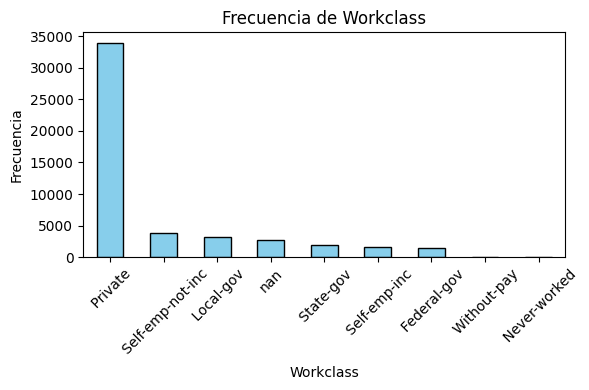

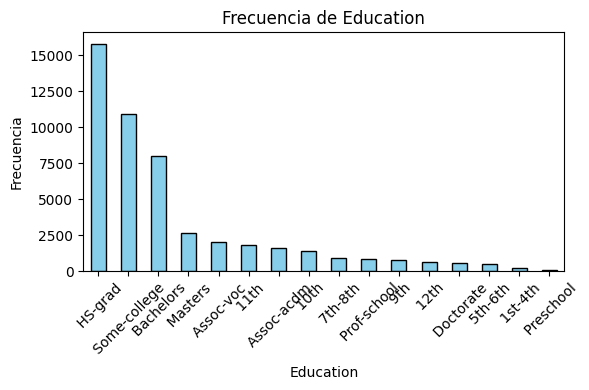

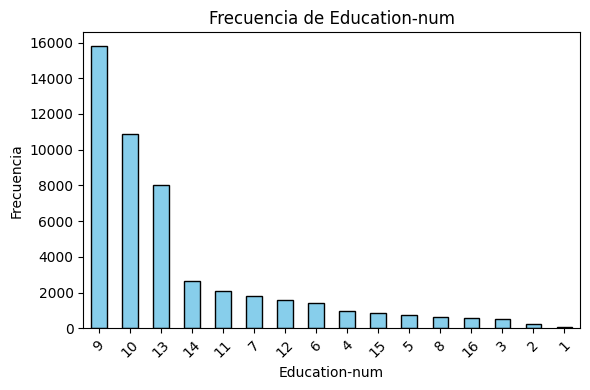

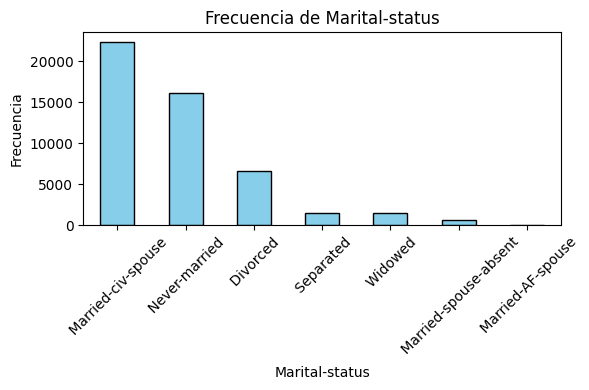

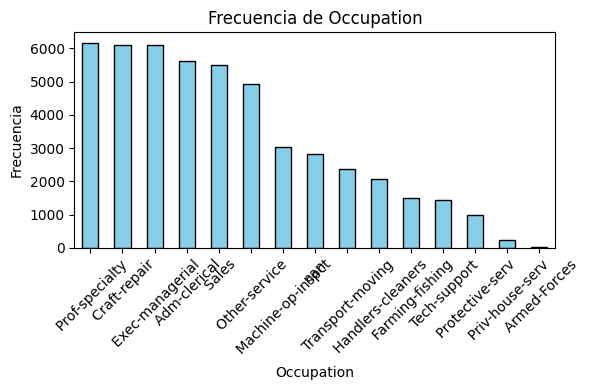

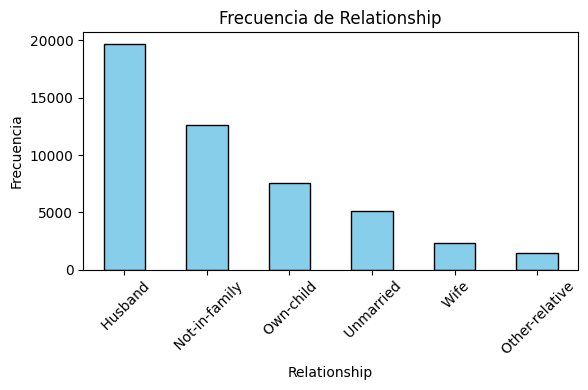

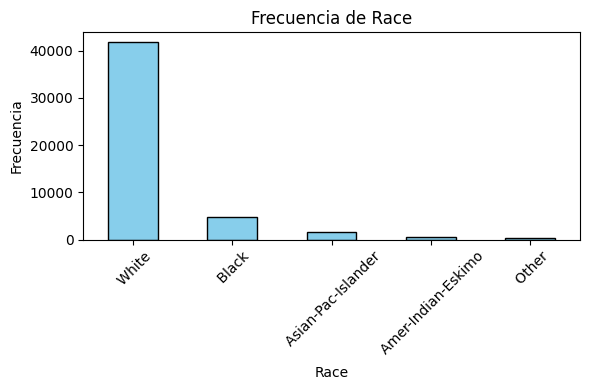

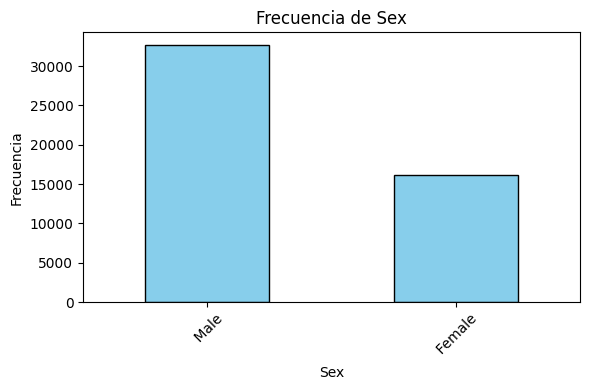

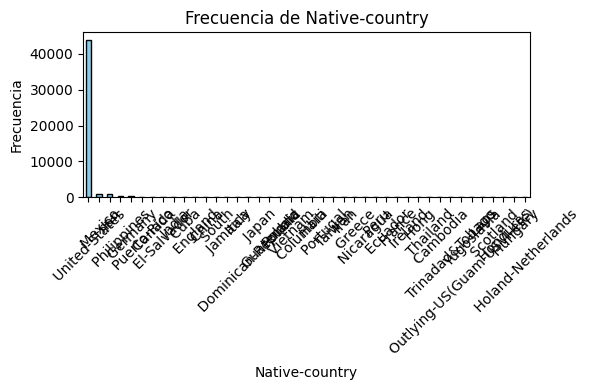

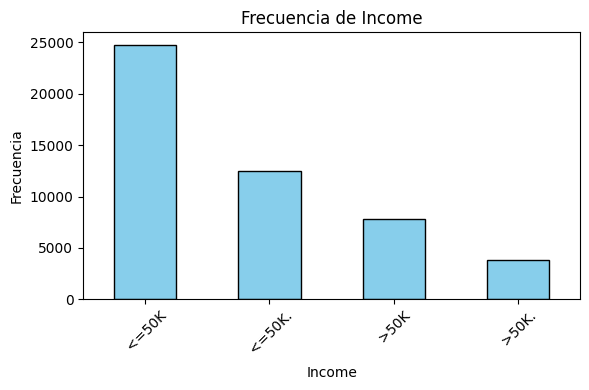

{'Workclass': Workclass
  Private             33906
  Self-emp-not-inc     3862
  Local-gov            3136
 NaN                   2799
  State-gov            1981
  Self-emp-inc         1695
  Federal-gov          1432
  Without-pay            21
  Never-worked           10
 Name: count, dtype: int64,
 'Education': Education
 HS-grad         15784
 Some-college    10878
 Bachelors        8025
 Masters          2657
 Assoc-voc        2061
 11th             1812
 Assoc-acdm       1601
 10th             1389
 7th-8th           955
 Prof-school       834
 9th               756
 12th              657
 Doctorate         594
 5th-6th           509
 1st-4th           247
 Preschool          83
 Name: count, dtype: int64,
 'Education-num': Education-num
 9     15784
 10    10878
 13     8025
 14     2657
 11     2061
 7      1812
 12     1601
 6      1389
 4       955
 15      834
 5       756
 8       657
 16      594
 3       509
 2       247
 1        83
 Name: count, dtype: int64,
 'Marita

In [51]:
GraficarCategoricas(df,"barra")

### Analisis exploratorio para variables numericas

In [53]:
resumen_numericas(df)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
Edad,6.0,32.666667,8.640988,23.00,26.000,31.50,38.5000,45.0,74.666667,31.50
Altura,6.0,1.716667,0.053166,1.65,1.685,1.71,1.7425,1.8,0.002827,1.71
Peso,6.0,72.500000,8.893818,60.00,68.500,71.00,78.0000,85.0,79.100000,71.00
